COMPARATIVA DE DETECCION DE BORDES

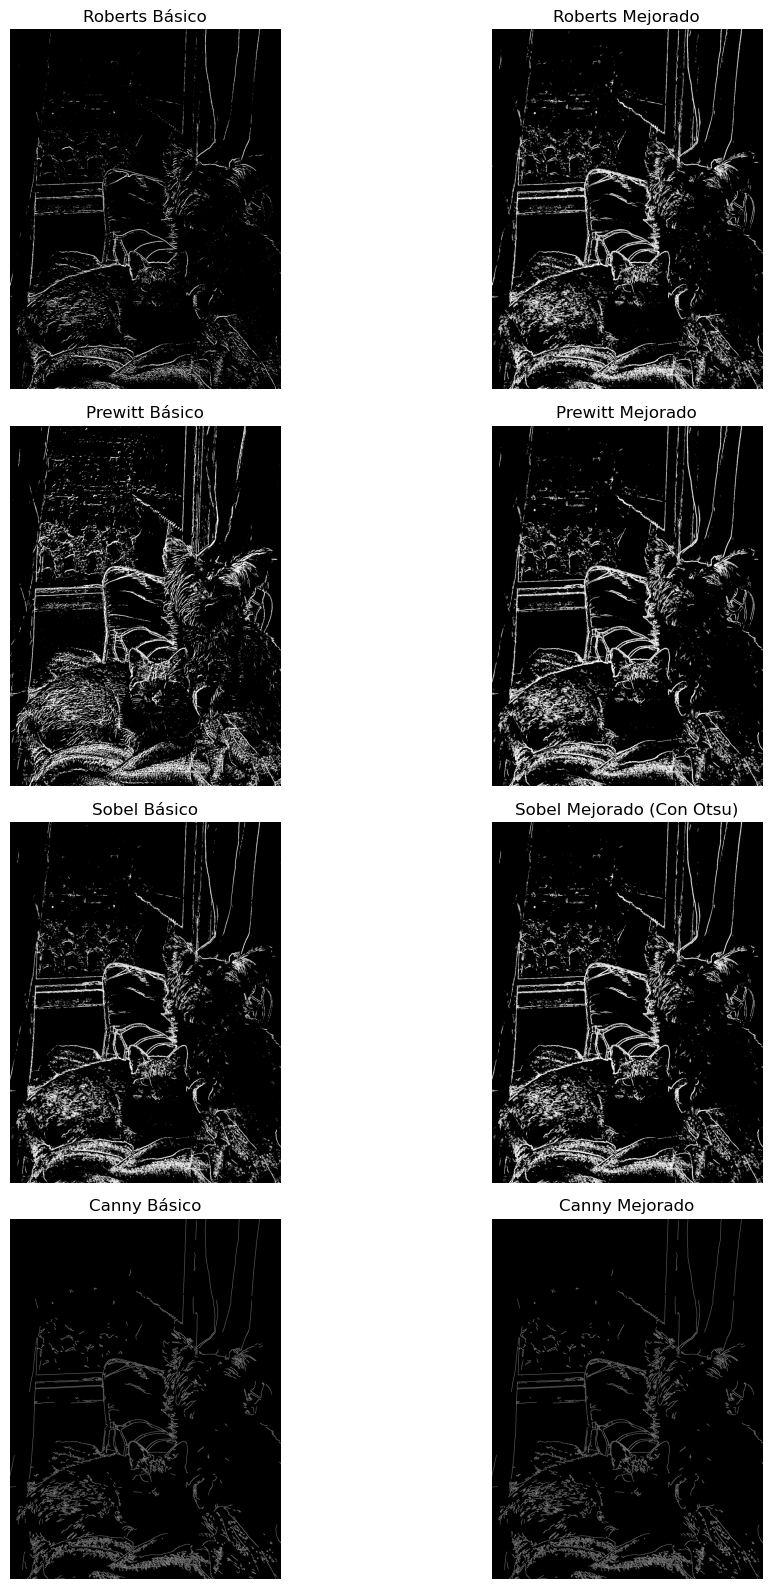

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


#  Funciones Básicas


def roberts_basic(imagen, umbral_val=30):
    # Convertir la imagen a escala de grises
    img_gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    # Definir kernels de Roberts básicos
    kernelX = np.array([[-1, 0], [0, 1]], dtype=np.float32)
    kernelY = np.array([[0, -1], [1, 0]], dtype=np.float32)
    # Aplicar convolución sin suavizado previo
    robX = cv2.filter2D(img_gray, -1, kernelX)
    robY = cv2.filter2D(img_gray, -1, kernelY)
    # Calcular la magnitud del gradiente (corrigiendo la fórmula)
    magnitud = np.sqrt(robX.astype(np.float32)**2 + robY.astype(np.float32)**2)
    # Normalizar al rango 0-255
    magnitud_norm = cv2.normalize(magnitud, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    # Umbralizar la imagen para obtener bordes binarios
    _, bordes = cv2.threshold(magnitud_norm, umbral_val, 255, cv2.THRESH_BINARY)
    return bordes

def prewitt_basic(imagen, umbral_val=30):
    img_gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    # Definir kernels Prewitt para X y Y
    kernelX = np.array([[1, 0, -1],
                        [1, 0, -1],
                        [1, 0, -1]], dtype=np.float32)
    kernelY = np.array([[1, 1, 1],
                        [0, 0, 0],
                        [-1, -1, -1]], dtype=np.float32)
    gradX = cv2.filter2D(img_gray, -1, kernelX)
    gradY = cv2.filter2D(img_gray, -1, kernelY)
    magnitud = np.sqrt(gradX.astype(np.float32)**2 + gradY.astype(np.float32)**2)
    magnitud_norm = cv2.normalize(magnitud, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    _, bordes = cv2.threshold(magnitud_norm, umbral_val, 255, cv2.THRESH_BINARY)
    return bordes

def sobel_basic(imagen, umbral_val=30):
    img_gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    sobX = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=3)
    sobY = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=3)
    magnitud = np.sqrt(sobX**2 + sobY**2)
    magnitud_norm = cv2.normalize(magnitud, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    _, bordes = cv2.threshold(magnitud_norm, umbral_val, 255, cv2.THRESH_BINARY)
    return bordes

def canny_basic(imagen):
    img_gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    suavizado = cv2.GaussianBlur(img_gray, (3, 3), 0)
    return cv2.Canny(suavizado, 100, 200)


#  Funciones Mejoradas


def roberts_mejorado(imagen, umbral_val=30, weight=0.7):
    img_gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    suavizado = cv2.GaussianBlur(img_gray, (3, 3), 0)
    kernelX = np.array([[-2, 0], [0, 2]], dtype=np.float32)
    kernelY = np.array([[0, 2], [-2, 0]], dtype=np.float32)
    grad_x = cv2.filter2D(suavizado, cv2.CV_16S, kernelX)
    grad_y = cv2.filter2D(suavizado, cv2.CV_16S, kernelY)
    abs_x = cv2.convertScaleAbs(grad_x)
    abs_y = cv2.convertScaleAbs(grad_y)
    roberts_improved = cv2.addWeighted(abs_x, weight, abs_y, weight, 0)
    _, bordes = cv2.threshold(roberts_improved, umbral_val, 255, cv2.THRESH_BINARY)
    return bordes

def prewitt_mejor(imagen, umbral_val=30):
    img_gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    suavizado = cv2.GaussianBlur(img_gray, (3, 3), 0)
    kernelX = np.array([[3, 0, -3],
                        [3, 0, -3],
                        [3, 0, -3]], dtype=np.float32)
    kernelY = np.array([[3, 3, 3],
                        [0, 0, 0],
                        [-3, -3, -3]], dtype=np.float32)
    grad_x = cv2.filter2D(suavizado, cv2.CV_64F, kernelX)
    grad_y = cv2.filter2D(suavizado, cv2.CV_64F, kernelY)
    magnitud = np.sqrt(grad_x**2 + grad_y**2)
    magnitud_norm = cv2.normalize(magnitud, None, 0, 255, cv2.NORM_MINMAX)
    magnitud_norm = magnitud_norm.astype(np.uint8)
    _, bordes = cv2.threshold(magnitud_norm, umbral_val, 255, cv2.THRESH_BINARY)
    return bordes

def sobel_mejorado(imagen, tam_kernel=3, umbral_val=30, usar_otsu=True):
    img_gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    suavizado = cv2.GaussianBlur(img_gray, (3, 3), 0)
    sobelX = cv2.Sobel(suavizado, cv2.CV_64F, 1, 0, ksize=tam_kernel)
    sobelY = cv2.Sobel(suavizado, cv2.CV_64F, 0, 1, ksize=tam_kernel)
    magnitud = np.sqrt(sobelX**2 + sobelY**2)
    magnitud_norm = cv2.normalize(magnitud, None, 0, 255, cv2.NORM_MINMAX)
    magnitud_norm = magnitud_norm.astype(np.uint8)
    if usar_otsu:
        _, bordes = cv2.threshold(magnitud_norm, umbral_val, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    else:
        _, bordes = cv2.threshold(magnitud_norm, umbral_val, 255, cv2.THRESH_BINARY)
    return bordes

def canny_mejorado(imagen):
    # En esta versión podemos considerar un suavizado adicional
    img_gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    suavizado = cv2.GaussianBlur(img_gray, (3, 3), 0)
    return cv2.Canny(suavizado, 100, 200)


# Leer imagen
img = cv2.imread('imagentango.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Obtener resultados básicos
roberts_basic_res = roberts_basic(img, umbral_val=30)
prewitt_basic_res = prewitt_basic(img, umbral_val=30)
sobel_basic_res = sobel_basic(img, umbral_val=30)
canny_basic_res = canny_basic(img)

# Obtener resultados mejorados
roberts_mej_res = roberts_mejorado(img, umbral_val=30, weight=0.7)
prewitt_mej_res = prewitt_mejor(img, umbral_val=30)
sobel_mej_res = sobel_mejorado(img, tam_kernel=3, umbral_val=30, usar_otsu=True)
canny_mej_res = canny_mejorado(img)  # Para Canny, usamos la misma función en ambas versiones

# Crear una figura con comparación: 4 filas (Roberts, Prewitt, Sobel, Canny) y 2 columnas (Básico vs Mejorado)
plt.figure(figsize=(12, 16))

# Roberts
plt.subplot(4, 2, 1)
plt.imshow(roberts_basic_res, cmap='gray')
plt.title("Roberts Básico")
plt.axis("off")

plt.subplot(4, 2, 2)
plt.imshow(roberts_mej_res, cmap='gray')
plt.title("Roberts Mejorado")
plt.axis("off")

# Prewitt
plt.subplot(4, 2, 3)
plt.imshow(prewitt_basic_res, cmap='gray')
plt.title("Prewitt Básico")
plt.axis("off")

plt.subplot(4, 2, 4)
plt.imshow(prewitt_mej_res, cmap='gray')
plt.title("Prewitt Mejorado")
plt.axis("off")

# Sobel
plt.subplot(4, 2, 5)
plt.imshow(sobel_basic_res, cmap='gray')
plt.title("Sobel Básico")
plt.axis("off")

plt.subplot(4, 2, 6)
plt.imshow(sobel_mej_res, cmap='gray')
plt.title("Sobel Mejorado (Con Otsu)")
plt.axis("off")

# Canny
plt.subplot(4, 2, 7)
plt.imshow(canny_basic_res, cmap='gray')
plt.title("Canny Básico")
plt.axis("off")

plt.subplot(4, 2, 8)
plt.imshow(canny_mej_res, cmap='gray')
plt.title("Canny Mejorado")
plt.axis("off")

plt.tight_layout()
plt.show()
